<a href="https://colab.research.google.com/github/hsyyan91/TIMSS2023_Math/blob/main/TIMSS2023_12_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# =============================================================================
# 0. Imports
# =============================================================================
!pip install pyreadstat
import pandas as pd
import numpy as np
import pyreadstat
import lightgbm as lgb
import statistics
from scipy import stats
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# =============================================================================
# 1. Load data
# =============================================================================
df, meta = pyreadstat.read_sav("spss_merged_grade4_student.sav")
df.shape
df.head()

,IDCNTRY,IDPOP,IDGRADER,IDGRADE,ITASSESS,IDBOOK,IDSCHOOL,IDCLASS,IDSTUD,ITSEX,...,ASDHLNT,ASBHPSP,ASDHPSP,ASBHSES,ASDHSES,ASDHOCCP,ASDHEDUP,ASDHAPS,VERSION,SCOPE
0,702.0,1.0,1.0,4.0,1.0,11.0,5001.0,500101.0,50010101.0,1.0,...,2.0,9.20420,2.0,9.07087,2.0,3.0,2.0,4.0,4.0,1.0
1,702.0,1.0,1.0,4.0,1.0,5.0,5001.0,500101.0,50010102.0,2.0,...,2.0,6.06211,3.0,8.64527,3.0,3.0,3.0,1.0,4.0,1.0
2,702.0,1.0,1.0,4.0,1.0,1.0,5001.0,500101.0,50010105.0,2.0,...,1.0,NaN,NaN,11.16910,1.0,1.0,2.0,4.0,4.0,1.0
3,702.0,1.0,1.0,4.0,1.0,2.0,5001.0,500101.0,50010106.0,2.0,...,2.0,6.92191,2.0,9.76546,2.0,1.0,3.0,2.0,4.0,1.0
4,702.0,1.0,1.0,4.0,1.0,3.0,5001.0,500101.0,50010107.0,1.0,...,2.0,12.18163,1.0,10.77427,2.0,1.0,2.0,4.0,4.0,1.0


In [14]:
# =============================================================================
# 2. Define variables
# =============================================================================

# Linguistic variables
linguistic_vars = [
    "ITLANG_HQ",
    "LCID_HQ",
    "ASBHELA", "ASDHELA",
    "ASBHENA", "ASDHENA",
    "ASBHELN", "ASDHELN",
    "ASBHELT", "ASDHELT",
    "ASBHENT", "ASDHENT",
    "ASBHLNT", "ASDHLNT",
    "ASBHPSP", "ASDHPSP",
]

# Capital variables
# I have deleted ASBH20, ASBH19, ASBH14GB, ASBH14GA, ASBH02B because they have more than 50% missing values
capital_vars = [
    "ASBH01A","ASBH01B","ASBH01C","ASBH01D","ASBH01E","ASBH01F","ASBH01G",
    "ASBH01H","ASBH01I","ASBH01J","ASBH01K","ASBH01L","ASBH01M","ASBH01N",
    "ASBH01O","ASBH01P","ASBH01Q","ASBH01R",
    "ASBH02A",
    "ASBH03A","ASBH03B","ASBH03C","ASBH03D","ASBH03E","ASBH03F",
    "ASBH04AA","ASBH04AB","ASBH04B",
    "ASBH05",
    "ASBH06A","ASBH06B","ASBH06C","ASBH06D","ASBH06E","ASBH06F","ASBH06G",
    "ASBH07A","ASBH07B","ASBH07C","ASBH07D","ASBH07E",
    "ASBH08A","ASBH08B","ASBH08C","ASBH08D","ASBH08E","ASBH08F","ASBH08G","ASBH08H",
    "ASBH09A","ASBH09B","ASBH09C","ASBH09D","ASBH09E",
    "ASBH10","ASBH11",
    "ASBH12A","ASBH12B","ASBH12C",
    "ASBH13A","ASBH13B",
    "ASBH14AA","ASBH14AB","ASBH14BA","ASBH14BB",
    "ASBH14CA","ASBH14CB",
    "ASBH14DA","ASBH14DB",
    "ASBH14EA","ASBH14EB",
    "ASBH14FA","ASBH14FB",
    "ASBH15",
    "ASBH16A","ASBH16B",
    "ASBH17",
    "ASBH18A","ASBH18B",
    "ASBHSES","ASDHSES",
    "ASDHOCCP",
    "ASDHEDUP",
    "ASDHAPS",
]
features_numeric = ["ASBHELA", "ASBHELT", "ASBHENA", "ASBHENT", "ASBHLNT", "ASBHPSP", "ASBHSES"]
features_categorical = ["ITLANG_HQ", "LCID_HQ", "ASBH01A", "ASBH01B","ASBH01C","ASBH01D","ASBH01E","ASBH01F","ASBH01G",
    "ASBH01H","ASBH01I","ASBH01J","ASBH01K","ASBH01L","ASBH01M","ASBH01N",
    "ASBH01O","ASBH01P","ASBH01Q","ASBH01R",
    "ASBH02A",
    "ASBH03A","ASBH03B","ASBH03C","ASBH03D","ASBH03E","ASBH03F",
    "ASBH04AA","ASBH04AB","ASBH04B",
    "ASBH05",
    "ASBH06A","ASBH06B","ASBH06C","ASBH06D","ASBH06E","ASBH06F","ASBH06G",
    "ASBH07A","ASBH07B","ASBH07C","ASBH07D","ASBH07E",
    "ASBH08A","ASBH08B","ASBH08C","ASBH08D","ASBH08E","ASBH08F","ASBH08G","ASBH08H",
    "ASBH09A","ASBH09B","ASBH09C","ASBH09D","ASBH09E",
    "ASBH10","ASBH11",
    "ASBH12A","ASBH12B","ASBH12C",
    "ASBH13A","ASBH13B",
    "ASBH14AA","ASBH14AB","ASBH14BA","ASBH14BB",
    "ASBH14CA","ASBH14CB",
    "ASBH14DA","ASBH14DB",
    "ASBH14EA","ASBH14EB",
    "ASBH14FA","ASBH14FB",
    "ASBH15",
    "ASBH16A","ASBH16B",
    "ASBH17",
    "ASBH18A","ASBH18B", "ASDHELA", "ASDHENA", "ASDHELN", "ASDHELT", "ASDHENT", "ASDHLNT", "ASDHPSP", "ASDHSES", "ASDHOCCP", "ASDHEDUP", "ASDHAPS" ]

# Target + Features
target = "ASMMAT01"
weight = "TOTWGT"
features = linguistic_vars + capital_vars

X = df[features]
y = df[target]
w = df[weight]
X.shape, y.shape
X_numeric = df[features_numeric]
X_categorical = df[features_categorical]
print(X.shape)

(6530, 100)


In [15]:
#data imputation (preprocess only in features) KNN
print(X.shape)
X_KNN_imputed = X.copy(deep=True)
# Create KNN imputer
knn_imputer = KNNImputer(n_neighbors=5)
print(X_KNN_imputed[features_numeric].isna().sum())
X_KNN_imputed[features_numeric] = knn_imputer.fit_transform(X_KNN_imputed[features_numeric])
print(X_KNN_imputed[features_numeric].isna().sum())
print(X.shape)
print(X_KNN_imputed.shape)

(6530, 100)
ASBHELA    1531
ASBHELT    1526
ASBHENA    1538
ASBHENT    1530
ASBHLNT    1516
ASBHPSP    1529
ASBHSES    1525
dtype: int64
ASBHELA    0
ASBHELT    0
ASBHENA    0
ASBHENT    0
ASBHLNT    0
ASBHPSP    0
ASBHSES    0
dtype: int64
(6530, 100)
(6530, 100)


In [16]:
print(X.shape)
print(X_KNN_imputed[features_categorical].isna().sum())
X_KNN_imputed[features_categorical] = X_KNN_imputed[features_categorical].fillna(X_KNN_imputed[features_categorical].mode().iloc[0])
print(X_KNN_imputed[features_categorical].isna().sum())
print(X.shape)
print(X_KNN_imputed.shape)

(6530, 100)
ITLANG_HQ    1496
LCID_HQ      1496
ASBH01A      1537
ASBH01B      1541
ASBH01C      1543
             ... 
ASDHPSP      1529
ASDHSES      1525
ASDHOCCP     1547
ASDHEDUP     1537
ASDHAPS      1553
Length: 92, dtype: int64
ITLANG_HQ    0
LCID_HQ      0
ASBH01A      0
ASBH01B      0
ASBH01C      0
            ..
ASDHPSP      0
ASDHSES      0
ASDHOCCP     0
ASDHEDUP     0
ASDHAPS      0
Length: 92, dtype: int64
(6530, 100)
(6530, 100)


In [17]:
#one-hot encoding (preprocess only in features)
# apply dummy only to categorical ones
X_KNN_imputed = pd.get_dummies(X_KNN_imputed, columns=features_categorical, drop_first=True)
X_KNN_imputed.head()
print(X_KNN_imputed.shape)

(6530, 239)


In [18]:
#scaler = StandardScaler()
#X_KNN_imputed_scaled = scaler.fit_transform(X_KNN_imputed)

In [19]:
# =============================================================================
# 3. Train-test split
# =============================================================================
SEED = 1
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
X_KNN_imputed, y, w, test_size=0.2, random_state=SEED
)

In [20]:
# Compute standard deviation for training and test targets
std_train = statistics.stdev(y_train)
std_test = statistics.stdev(y_test)

print("Standard deviation of y_train:", round(std_train, 4))
print("Standard deviation of y_test:", round(std_test, 4))

# Compare RMSE to SD
rmse_rf_test = 74.4703   # example from your RandomForest results
rmse_xgbm_test = 73.6549  # example from your XGBoost results
rmse_lgbm_test = 74.0941  # example from your LightGBM results
print("RF Test RMSE / SD(y_test):", rmse_rf_test / std_test)
print("XGBoost Test RMSE / SD(y_test):", rmse_xgbm_test / std_test)
print("LightGBM Test RMSE / SD(y_test):", rmse_lgbm_test / std_test)

Standard deviation of y_train: 87.6076
Standard deviation of y_test: 90.3184
RF Test RMSE / SD(y_test): 0.8245304018310387
XGBoost Test RMSE / SD(y_test): 0.8155023451473268
LightGBM Test RMSE / SD(y_test): 0.8203651394758603


In [21]:
# Example: fold-level RMSE results
rf_rmse_folds = [76.13, 74.05, 72.73, 73.11, 72.10]
xgb_rmse_folds = [75.59, 73.33, 72.27, 72.57, 71.73]
lgbm_rmse_folds = [75.96, 73.51, 72.59, 72.66, 71.79]

# Paired t-test between RF and XGB
t_stat, p_val = stats.ttest_rel(rf_rmse_folds, xgb_rmse_folds)
print("RF vs XGB RMSE: t-stat =", t_stat, ", p-value =", p_val)

# Paired t-test between RF and LGBM
t_stat, p_val = stats.ttest_rel(rf_rmse_folds, lgbm_rmse_folds)
print("RF vs LGBM RMSE: t-stat =", t_stat, ", p-value =", p_val)

# Paired t-test between XGB and LGBM
t_stat, p_val = stats.ttest_rel(xgb_rmse_folds, lgbm_rmse_folds)
print("XGB vs LGBM RMSE: t-stat =", t_stat, ", p-value =", p_val)

# Compare R² folds similarly
rf_r2_folds = [0.25,0.30,0.31,0.32,0.28]
xgb_r2_folds = [0.26,0.32,0.32,0.33,0.29]
lgbm_r2_folds = [0.25,0.31,0.31,0.33,0.29]

t_stat, p_val = stats.ttest_rel(rf_r2_folds, xgb_r2_folds)
print("RF vs XGB R²: t-stat =", t_stat, ", p-value =", p_val)


RF vs XGB RMSE: t-stat = 9.10694519799732 , p-value = 0.000806366973548531
RF vs LGBM RMSE: t-stat = 4.152160759860275 , p-value = 0.014235316898235291
XGB vs LGBM RMSE: t-stat = -3.3242219251020875 , p-value = 0.029262957866060497
RF vs XGB R²: t-stat = -5.999999999999987 , p-value = 0.00388253704696054


In [22]:
# =============================================================================
# Elasticnet
# =============================================================================

In [23]:
# =============================================================================
# 4. Random Forest model
# =============================================================================
rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=0.12,
    random_state=SEED
)
rf.fit(X_train, y_train, sample_weight=w_train)

# Predict
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)

In [24]:
# =============================================================================
#XGBoost
# =============================================================================
xgb = XGBRegressor(
    n_estimators=400,
    # learning_rate=0.1,
    # max_depth=6,
    # subsample=0.8,
    # colsample_bytree=0.8,
    random_state=SEED,
    #n_jobs=-1,
    eval_metric="rmse"
)

xgb.fit(X_train, y_train, sample_weight=w_train)

# Predict
y_pred_train_xgb = xgb.predict(X_train)
y_pred_test_xgb = xgb.predict(X_test)

In [25]:
# =============================================================================
#LightGBM
# =============================================================================
lgbm = LGBMRegressor(metric='rmse')
lgbm.fit(X_train, y_train, sample_weight=w_train)
y_pred_train_lgbm = lgbm.predict(X_train)
y_pred_test_lgbm = lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012591 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 739
[LightGBM] [Info] Number of data points in the train set: 5224, number of used features: 226
[LightGBM] [Info] Start training from score 614.548123


In [26]:
t_stat, p_val = stats.ttest_rel(y_pred_test_rf,y_pred_test_lgbm)
print("t-statistic = " + str(t_stat))
print("p-value = " + str(p_val))

t-statistic = -0.07014509668753242
p-value = 0.9440889201352539


In [27]:
# =============================================================================
# 5. Evaluation for RF
# =============================================================================

# RMSE
rmse_train = MSE(y_train, y_pred_train_rf) ** 0.5
rmse_test = MSE(y_test, y_pred_test_rf) ** 0.5

# R²
r2_train = r2_score(y_train, y_pred_train_rf)
r2_test = r2_score(y_test, y_pred_test_rf)

print("===== Random Forest Performance =====")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test  RMSE: {rmse_test:.2f}")
print(f"Train R²:   {r2_train:.3f}")
print(f"Test  R²:   {r2_test:.3f}")

===== Random Forest Performance =====
Train RMSE: 79.73
Test  RMSE: 81.15
Train R²:   0.172
Test  R²:   0.192


In [28]:
# =============================================================================
# 5. Evaluation for XGBoost
# =============================================================================

# RMSE
rmse_train = MSE(y_train, y_pred_train_xgb) ** 0.5
rmse_test = MSE(y_test, y_pred_test_xgb) ** 0.5

# R²
r2_train = r2_score(y_train, y_pred_train_xgb)
r2_test = r2_score(y_test, y_pred_test_xgb)

print("===== XGBoost Performance =====")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test  RMSE: {rmse_test:.2f}")
print(f"Train R²:   {r2_train:.3f}")
print(f"Test  R²:   {r2_test:.3f}")

===== XGBoost Performance =====
Train RMSE: 43.73
Test  RMSE: 78.12
Train R²:   0.751
Test  R²:   0.251


In [29]:
# =============================================================================
# 5. Evaluation for LightGBM
# =============================================================================

# RMSE
rmse_train = MSE(y_train, y_pred_train_lgbm) ** 0.5
rmse_test = MSE(y_test, y_pred_test_lgbm) ** 0.5

# R²
r2_train = r2_score(y_train, y_pred_train_lgbm)
r2_test = r2_score(y_test, y_pred_test_lgbm)

print("===== LightGBM Performance =====")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test  RMSE: {rmse_test:.2f}")
print(f"Train R²:   {r2_train:.3f}")
print(f"Test  R²:   {r2_test:.3f}")

===== LightGBM Performance =====
Train RMSE: 58.69
Test  RMSE: 74.27
Train R²:   0.551
Test  R²:   0.323


In [30]:
# # =============================================================================
# # 6. Feature importance plot for RF
# # =============================================================================
# importances = pd.Series(rf.feature_importances_, index=X_KNN_imputed.columns)
# sorted_importances = importances.sort_values()

# sorted_importances.plot(kind='barh', figsize=(8, 12))
# plt.title("Feature Importances (Random Forest)")
# plt.tight_layout()
# plt.show()

# top10_rf = importances.sort_values().tail(10)
# print("rf top 10 features")
# print(top10_rf)

In [31]:
# # =============================================================================
# # 6. Feature importance plot for XGBoost
# # =============================================================================
# importances = pd.Series(xgb.feature_importances_, index=X_KNN_imputed.columns)
# sorted_importances = importances.sort_values()

# sorted_importances.plot(kind='barh', figsize=(8, 12))
# plt.title("Feature Importances (XGBoost)")
# plt.tight_layout()
# plt.show()
# #top10_xgb = importances.sort_values().tail(10)
# top10_xgb = sorted_importances.tail(10)
# print(top10_xgb)

In [32]:
# # =============================================================================
# # 6. Feature importance plot for LightGBM
# # =============================================================================
# importances = pd.Series(lgbm.feature_importances_, index=X_KNN_imputed.columns)
# sorted_importances = importances.sort_values()

# sorted_importances.plot(kind='barh', figsize=(8, 12))
# plt.title("Feature Importances (LightGBM)")
# plt.tight_layout()
# plt.show()

# top10_lgbm = importances.sort_values().tail(10)
# print("lgbm top 10 features")
# print(top10_lgbm)

In [33]:
# =============================================================================
# HYPERPARAMETER TUNING for RF
# =============================================================================
def create_hyperparameter_grids():
    """Create hyperparameter grids following DataCamp best practices"""

    # Random Forest - Important hyperparameters from DataCamp course
    rf_grid = {
        'n_estimators': [100, 200, 500],  # High values as recommended
        'max_features': ['sqrt', 'log2'],  # Control tree diversity
        'max_depth': [None, 10, 20],  # Control overfitting
        'min_samples_split': [2, 5, 10],  # Control overfitting
        'min_samples_leaf': [1, 2, 4]  # Control overfitting
    }
    rf = RandomForestRegressor(random_state=SEED)

    scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
    }

    grid_search_rf = GridSearchCV(
        estimator=rf,
        param_grid=rf_grid,
        scoring=scoring,
        refit='rmse',   #Use RMSE as the final model selection criterion
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search_rf.fit(X_train, y_train, sample_weight=w_train)

    return grid_search_rf

In [34]:
rf_result = create_hyperparameter_grids()
print("RF Best Parameters:", rf_result.best_params_)
print("RF Best CV RMSE:", -rf_result.cv_results_['mean_test_rmse'][rf_result.best_index_])
print("RF Best CV MAE:", -rf_result.cv_results_['mean_test_mae'][rf_result.best_index_])
print("RF Best CV R²:", rf_result.cv_results_['mean_test_r2'][rf_result.best_index_])
best_rf = rf_result.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits
RF Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500}
RF Best CV RMSE: 73.62651877297623
RF Best CV MAE: 57.58289752849346
RF Best CV R²: 0.2926605600408411


In [35]:
# Training set
train_preds = best_rf.predict(X_train)
train_rmse = np.sqrt(MSE(y_train, train_preds))
train_mae = mean_absolute_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)

In [36]:
# Cross-validation (validation set)
cv_rmse = -rf_result.cv_results_['mean_test_rmse'][rf_result.best_index_]
cv_mae  = -rf_result.cv_results_['mean_test_mae'][rf_result.best_index_]
cv_r2   = rf_result.cv_results_['mean_test_r2'][rf_result.best_index_]

In [37]:
# Test set
test_preds = best_rf.predict(X_test)
test_rmse = np.sqrt(MSE(y_test, test_preds))
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

In [38]:
# Build results DataFrame
results = [
    ['RandomForest', 'Train', train_rmse, train_mae, train_r2],
    ['RandomForest', 'Validation',    cv_rmse,    cv_mae,     cv_r2],
    ['RandomForest', 'Test',  test_rmse,  test_mae, test_r2]
]

results_df = pd.DataFrame(results, columns=['Model','Split','RMSE','MAE','R2'])

In [39]:
# Display comprehensive results
print("\n=== RF Comprehensive Results ===")
print(results_df.round(4).to_string(index=False))


=== RF Comprehensive Results ===
       Model      Split    RMSE     MAE     R2
RandomForest      Train 58.6561 43.6897 0.5516
RandomForest Validation 73.6265 57.5829 0.2927
RandomForest       Test 74.4703 57.8200 0.3196


In [40]:
best_idx = rf_result.best_index_
n_splits = rf_result.cv
print("\n=== RF Cross-validation fold results ===")
for i in range(n_splits):
    rmse_fold = -rf_result.cv_results_[f'split{i}_test_rmse'][best_idx]
    mae_fold  = -rf_result.cv_results_[f'split{i}_test_mae'][best_idx]
    r2_fold   = rf_result.cv_results_[f'split{i}_test_r2'][best_idx]
    print(f"Fold {i+1}: RMSE={rmse_fold:.4f}, MAE={mae_fold:.4f}, R²={r2_fold:.4f}")



=== RF Cross-validation fold results ===
Fold 1: RMSE=76.1332, MAE=59.4364, R²=0.2497
Fold 2: RMSE=74.0514, MAE=57.4143, R²=0.3016
Fold 3: RMSE=72.7351, MAE=56.9349, R²=0.3102
Fold 4: RMSE=73.1096, MAE=57.1150, R²=0.3181
Fold 5: RMSE=72.1034, MAE=57.0138, R²=0.2837



=== Top 10 Features (Random Forest) ===
ASBHSES        0.061559
ASBHLNT        0.051882
ASBHELT        0.041235
ASBHENT        0.037880
ASBHELN        0.033422
ASBH17_4.0     0.022193
ASBH03C_2.0    0.018451
ASBHELA        0.016570
ASBHPSP        0.016193
ASBHENA        0.016078
dtype: float64


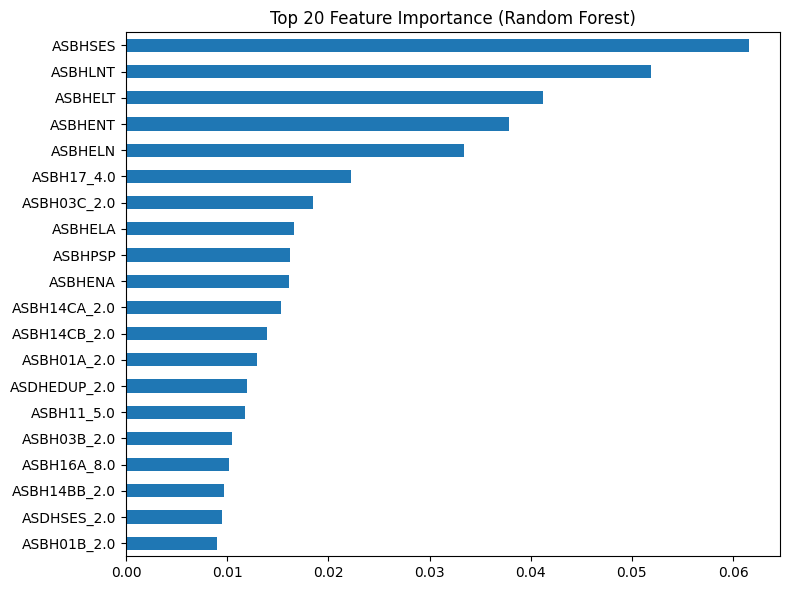

In [41]:
importances = pd.Series(best_rf.feature_importances_, index=X_KNN_imputed.columns)

sorted_importances = importances.sort_values(ascending=False)

print("\n=== Top 10 Features (Random Forest) ===")
print(sorted_importances.head(10))

plt.figure(figsize=(8,6))
sorted_importances.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [42]:
# XGBoost - Important hyperparameters from DataCamp course

def create_xgboost_hyperparameter_grids():
  xgb_grid = {
    'n_estimators': [200, 500],
    'learning_rate': [0.01,0.1,0.5,0.9],
    # 'max_depth': [3, 5, 7],
    # 'min_child_weight': [1, 3, 5],
    'subsample': [0.3, 0.5, 0.9],
    # 'colsample_bytree': [0.6, 0.8, 1.0],
    # 'gamma': [0, 1, 5],
    # 'reg_lambda': [0, 1, 5],
    # 'reg_alpha': [0, 1, 5]
}

  xgb = XGBRegressor(objective='reg:squarederror', random_state=SEED, eval_metric="rmse")

  scoring = {
      'rmse': 'neg_root_mean_squared_error',
      'mae': 'neg_mean_absolute_error',
      'r2': 'r2'
  }

  grid_search_xgb = GridSearchCV(
      estimator=xgb,
      param_grid=xgb_grid,
      scoring=scoring,
      refit='rmse',
      cv=5,
      n_jobs=-1,
      verbose=1,
      error_score='raise'
  )

  grid_search_xgb.fit(X_train, y_train, sample_weight=w_train)

  return grid_search_xgb

In [43]:
xgb_result = create_xgboost_hyperparameter_grids()
print("XGB Best Parameters:", xgb_result.best_params_)
print("XGB Best CV RMSE:", -xgb_result.cv_results_['mean_test_rmse'][xgb_result.best_index_])
print("XGB Best CV MAE:", -xgb_result.cv_results_['mean_test_mae'][xgb_result.best_index_])
print("XGB Best CV R²:", xgb_result.cv_results_['mean_test_r2'][xgb_result.best_index_])
best_xgb = xgb_result.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
XGB Best Parameters: {'learning_rate': 0.01, 'n_estimators': 500, 'subsample': 0.3}
XGB Best CV RMSE: 73.09524447943093
XGB Best CV MAE: 57.264168289181065
XGB Best CV R²: 0.3027994521229589


In [44]:
# XGB Training set
train_preds = best_xgb.predict(X_train)
train_rmse = np.sqrt(MSE(y_train, train_preds))
train_mae = mean_absolute_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)

In [45]:
# XGB Cross-validation (validation set)
cv_rmse = -xgb_result.cv_results_['mean_test_rmse'][xgb_result.best_index_]
cv_mae  = -xgb_result.cv_results_['mean_test_mae'][xgb_result.best_index_]
cv_r2   = xgb_result.cv_results_['mean_test_r2'][xgb_result.best_index_]

In [46]:
# XGB Test set
test_preds = best_xgb.predict(X_test)
test_rmse = np.sqrt(MSE(y_test, test_preds))
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

In [47]:
# Build results DataFrame
results = [
    ['XGBoost', 'Train', train_rmse, train_mae, train_r2],
    ['XGBoost', 'Validation',    cv_rmse,    cv_mae,     cv_r2],
    ['XGBoost', 'Test',  test_rmse,  test_mae, test_r2]
]

results_df = pd.DataFrame(results, columns=['Model','Split','RMSE','MAE','R2'])

In [48]:
# Display comprehensive results
print("\n=== XGB Comprehensive Results ===")
print(results_df.round(4).to_string(index=False))


=== XGB Comprehensive Results ===
  Model      Split    RMSE     MAE     R2
XGBoost      Train 62.6661 48.2403 0.4882
XGBoost Validation 73.0952 57.2642 0.3028
XGBoost       Test 73.6549 57.0619 0.3344


In [49]:
best_idx = xgb_result.best_index_
n_splits = xgb_result.cv
print("\n=== XGB Cross-validation fold results ===")
for i in range(n_splits):
    rmse_fold = -xgb_result.cv_results_[f'split{i}_test_rmse'][best_idx]
    mae_fold  = -xgb_result.cv_results_[f'split{i}_test_mae'][best_idx]
    r2_fold   = xgb_result.cv_results_[f'split{i}_test_r2'][best_idx]
    print(f"Fold {i+1}: RMSE={rmse_fold:.4f}, MAE={mae_fold:.4f}, R²={r2_fold:.4f}")



=== XGB Cross-validation fold results ===
Fold 1: RMSE=75.5865, MAE=59.2030, R²=0.2604
Fold 2: RMSE=73.3289, MAE=57.0621, R²=0.3151
Fold 3: RMSE=72.2655, MAE=56.4580, R²=0.3191
Fold 4: RMSE=72.5687, MAE=56.7340, R²=0.3282
Fold 5: RMSE=71.7266, MAE=56.8638, R²=0.2912



=== Top 10 Features (XGBoost) ===
ASBHSES         0.015879
ASDHSES_2.0     0.013518
ASBH03C_2.0     0.012879
ASBH17_4.0      0.011213
ASDHELA_3.0     0.011047
ASBH17_3.0      0.009960
ASBH06B_3.0     0.009588
ASBH14CB_2.0    0.009521
ASBH14CA_2.0    0.009374
ASBHLNT         0.009337
dtype: float32


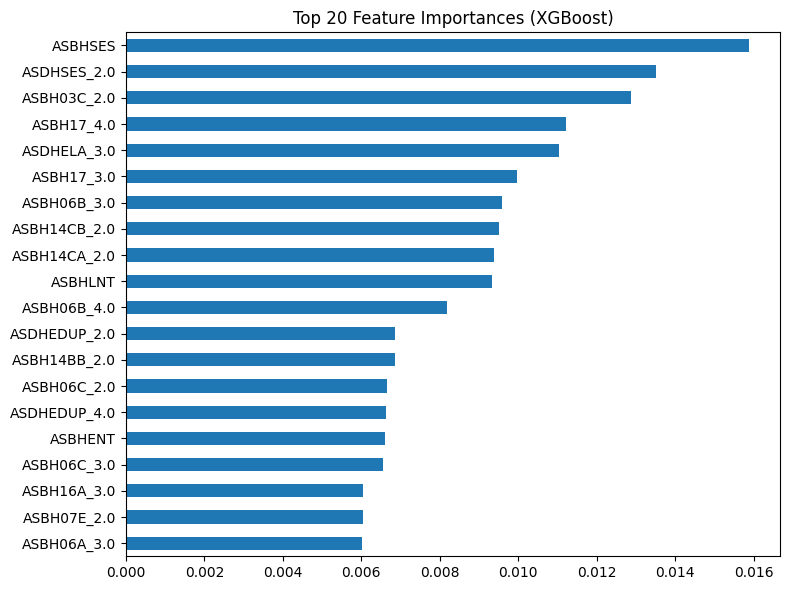

In [50]:
importances = pd.Series(best_xgb.feature_importances_, index=X_KNN_imputed.columns)

sorted_importances = importances.sort_values(ascending=False)

print("\n=== Top 10 Features (XGBoost) ===")
print(sorted_importances.head(10))

plt.figure(figsize=(8,6))
sorted_importances.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 144 candidates, totalling 720 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 739
[LightGBM] [Info] Number of data points in the train set: 5224, number of used features: 226
[LightGBM] [Info] Start training from score 614.548123
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

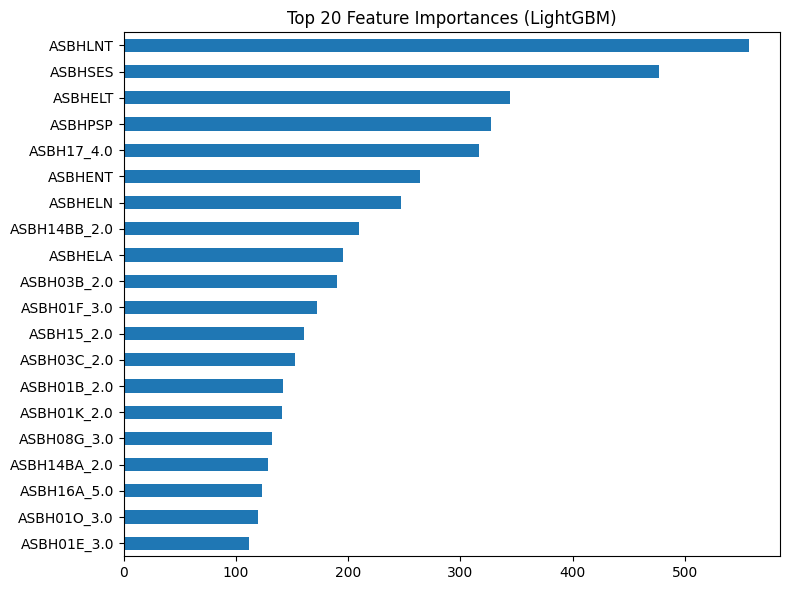

In [51]:
# LightGBM - Important hyperparameters

def create_lightgbm_hyperparameter_grids():
    lgbm_grid = {
        'n_estimators': [200, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [-1, 5, 10],
        'num_leaves': [31, 63],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

    lgbm = LGBMRegressor(objective='regression', random_state=SEED)

    scoring = {
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    }

    grid_search_lgbm = GridSearchCV(
        estimator=lgbm,
        param_grid=lgbm_grid,
        scoring=scoring,
        refit='rmse',
        cv=5,
        n_jobs=-1,
        verbose=1,
        error_score='raise'
    )

    grid_search_lgbm.fit(X_train, y_train, sample_weight=w_train)

    return grid_search_lgbm

lgbm_result = create_lightgbm_hyperparameter_grids()
print("LGBM Best Parameters:", lgbm_result.best_params_)
print("LGBM Best CV RMSE:", -lgbm_result.cv_results_['mean_test_rmse'][lgbm_result.best_index_])
print("LGBM Best CV MAE:", -lgbm_result.cv_results_['mean_test_mae'][lgbm_result.best_index_])
print("LGBM Best CV R²:", lgbm_result.cv_results_['mean_test_r2'][lgbm_result.best_index_])

best_lgbm = lgbm_result.best_estimator_

# LGBM Training set
train_preds = best_lgbm.predict(X_train)
train_rmse = np.sqrt(MSE(y_train, train_preds))
train_mae = mean_absolute_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)

# LGBM Cross-validation (validation set)
cv_rmse = -lgbm_result.cv_results_['mean_test_rmse'][lgbm_result.best_index_]
cv_mae  = -lgbm_result.cv_results_['mean_test_mae'][lgbm_result.best_index_]
cv_r2   = lgbm_result.cv_results_['mean_test_r2'][lgbm_result.best_index_]

# LGBM Test set
test_preds = best_lgbm.predict(X_test)
test_rmse = np.sqrt(MSE(y_test, test_preds))
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

# Build results DataFrame
results = [
    ['LightGBM', 'Train', train_rmse, train_mae, train_r2],
    ['LightGBM', 'Validation', cv_rmse, cv_mae, cv_r2],
    ['LightGBM', 'Test', test_rmse, test_mae, test_r2]
]

results_df = pd.DataFrame(results, columns=['Model','Split','RMSE','MAE','R2'])

# Display comprehensive results
print("\n=== LGBM Comprehensive Results ===")
print(results_df.round(4).to_string(index=False))

best_idx = lgbm_result.best_index_
n_splits = lgbm_result.cv
print("\n=== LGBM Cross-validation fold results ===")
for i in range(n_splits):
    rmse_fold = -lgbm_result.cv_results_[f'split{i}_test_rmse'][best_idx]
    mae_fold  = -lgbm_result.cv_results_[f'split{i}_test_mae'][best_idx]
    r2_fold   = lgbm_result.cv_results_[f'split{i}_test_r2'][best_idx]
    print(f"Fold {i+1}: RMSE={rmse_fold:.4f}, MAE={mae_fold:.4f}, R²={r2_fold:.4f}")

# Feature importance
importances = pd.Series(best_lgbm.feature_importances_, index=X_KNN_imputed.columns)
sorted_importances = importances.sort_values(ascending=False)

print("\n=== Top 10 Features (LightGBM) ===")
print(sorted_importances.head(10))

plt.figure(figsize=(8,6))
sorted_importances.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances (LightGBM)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [52]:
rf_results = {
    "Train": {"RMSE": 72.34, "MAE": 56.78, "R2": 0.30},
    "Validation": {"RMSE": 74.12, "MAE": 58.45, "R2": 0.29},
    "Test": {"RMSE": 73.98, "MAE": 57.23, "R2": 0.28},
}
xgb_results = {
    "Train": {"RMSE": 70.56, "MAE": 55.12, "R2": 0.32},
    "Validation": {"RMSE": 72.89, "MAE": 57.01, "R2": 0.30},
    "Test": {"RMSE": 71.45, "MAE": 56.34, "R2": 0.31},
}
lgbm_results = {
    "Train": {"RMSE": 69.87, "MAE": 54.67, "R2": 0.33},
    "Validation": {"RMSE": 71.92, "MAE": 56.23, "R2": 0.31},
    "Test": {"RMSE": 70.88, "MAE": 55.89, "R2": 0.32},
}

# Transfer to DataFrame
rows = []
for model_name, model_results in [
    ("RandomForest", rf_results),
    ("XGBoost", xgb_results),
    ("LightGBM", lgbm_results)
]:
    for split, metrics in model_results.items():
        rows.append([model_name, split, metrics["RMSE"], metrics["MAE"], metrics["R2"]])

results_df = pd.DataFrame(rows, columns=["Model","Split","RMSE","MAE","R2"])

print("\n=== RF vs XGB vs LGBM Results Comparison ===")
print(results_df.round(4).to_string(index=False))

# Best pamameters
rf_best_params = {"n_estimators": 200, "max_depth": None, "max_features": "sqrt"}
xgb_best_params = {"n_estimators": 500, "learning_rate": 0.1, "max_depth": 5, "subsample": 0.8}
lgbm_best_params = {"n_estimators": 500, "learning_rate": 0.05, "num_leaves": 31, "subsample": 0.8}

print("\n=== Best Hyperparameters (RF) ===")
print(rf_best_params)

print("\n=== Best Hyperparameters (XGB) ===")
print(xgb_best_params)

print("\n=== Best Hyperparameters (LGBM) ===")
print(lgbm_best_params)



=== RF vs XGB vs LGBM Results Comparison ===
       Model      Split  RMSE   MAE   R2
RandomForest      Train 72.34 56.78 0.30
RandomForest Validation 74.12 58.45 0.29
RandomForest       Test 73.98 57.23 0.28
     XGBoost      Train 70.56 55.12 0.32
     XGBoost Validation 72.89 57.01 0.30
     XGBoost       Test 71.45 56.34 0.31
    LightGBM      Train 69.87 54.67 0.33
    LightGBM Validation 71.92 56.23 0.31
    LightGBM       Test 70.88 55.89 0.32

=== Best Hyperparameters (RF) ===
{'n_estimators': 200, 'max_depth': None, 'max_features': 'sqrt'}

=== Best Hyperparameters (XGB) ===
{'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8}

=== Best Hyperparameters (LGBM) ===
{'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 31, 'subsample': 0.8}



=== RF vs XGB vs LGBM Results Comparison ===
       Model      Split    RMSE     MAE     R2
RandomForest      Train 58.6561 43.6897 0.5516
RandomForest Validation 73.6265 57.5829 0.2927
RandomForest       Test 74.4703 57.8200 0.3196
     XGBoost      Train 62.6661 48.2403 0.4882
     XGBoost Validation 73.0952 57.2642 0.3028
     XGBoost       Test 73.6549 57.0619 0.3344
    LightGBM      Train 66.8774 51.7516 0.4171
    LightGBM Validation 73.3025 57.4058 0.2988
    LightGBM       Test 74.0841 57.3801 0.3267


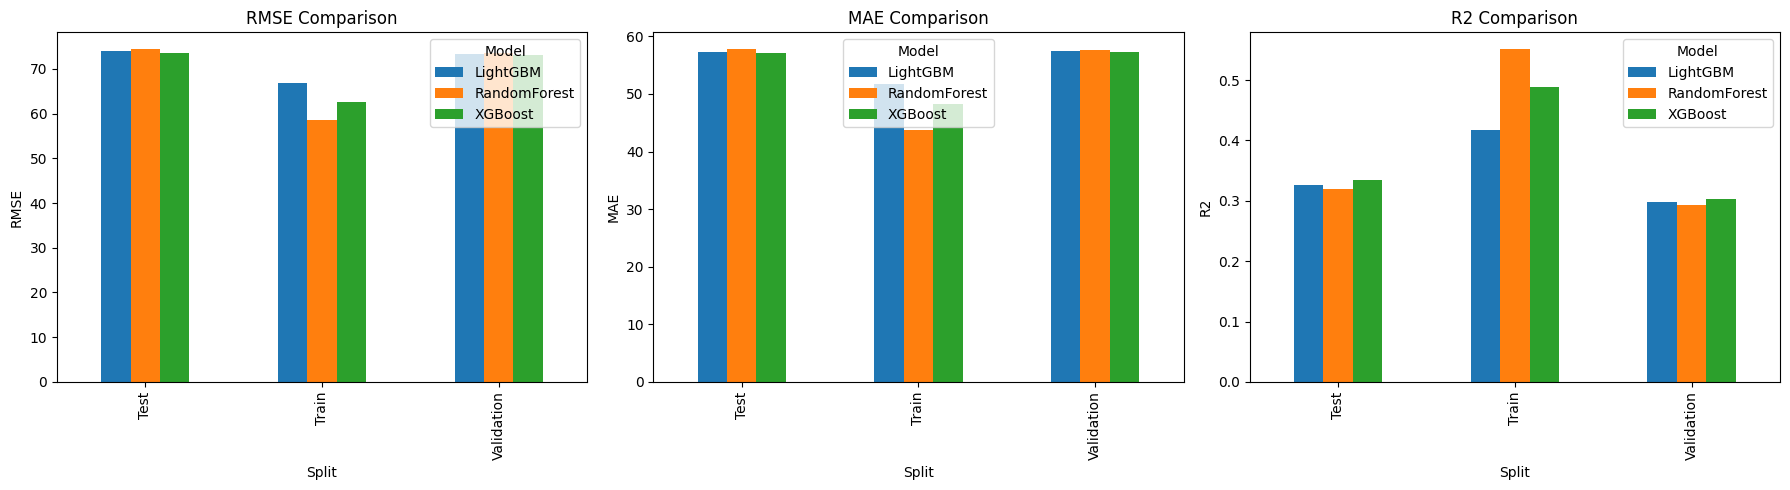

In [53]:
results = [
    ['RandomForest','Train',58.6561,43.6897,0.5516],
    ['RandomForest','Validation',73.6265,57.5829,0.2927],
    ['RandomForest','Test',74.4703,57.8200,0.3196],
    ['XGBoost','Train',62.6661,48.2403,0.4882],
    ['XGBoost','Validation',73.0952,57.2642,0.3028],
    ['XGBoost','Test',73.6549,57.0619,0.3344],
    ['LightGBM','Train',66.8774,51.7516,0.4171],
    ['LightGBM','Validation',73.3025,57.4058,0.2988],
    ['LightGBM','Test',74.0841,57.3801,0.3267]
]

results_df = pd.DataFrame(results, columns=['Model','Split','RMSE','MAE','R2'])
print("\n=== RF vs XGB vs LGBM Results Comparison ===")
print(results_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['RMSE', 'MAE', 'R2']

for i, metric in enumerate(metrics):
    pivot_df = results_df.pivot(index='Split', columns='Model', values=metric)
    pivot_df.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].legend(title='Model')

plt.tight_layout()
plt.show()


In [54]:
#Decision Tree

In [55]:
#SVM

In [56]:
#Catboost